# Prompt Robustness Sweep

**Goal:** Determine which prompt configurations generalize best across models and tasks for the LEVANTE benchmark.

## Experiment Design

We decompose each prompt into two orthogonal factors:

- **Task Framing (TF):** How the cognitive challenge is presented to the model (e.g., minimal, elimination, feature-grounded, step-by-step).
- **Output Format (OF):** How the model is instructed to respond (e.g., bare letter, JSON, structured tags).

Each task has 4 TF variants × 3 OF variants = **12 prompt cells** per task.
CoT (chain-of-thought) was excluded from OF because it is 3-4× slower and yields low parse rates.

### Models (1 per family)
| Model | Family | Size | VRAM |
|-------|--------|------|------|
| Qwen2.5-VL | qwen | 0.8B | ~4 GB |
| InternVL3.5 | internvl | 1B | ~4 GB |
| SmolVLM2 | smolvlm | 2.2B | ~20 GB |

### Tasks
| Task | Trials | Options | Context type |
|------|--------|---------|--------------|
| mental-rotation | 83 | 2 (A/B) | image + image options |
| matrix-reasoning | 80 | 4 (A-D) | image + image options |
| vocab | 170 | 4 (A-D) | image options only |
| trog | 99 | 4 (A-D) | image options only |
| theory-of-mind | 37 | 2 (A/B) | text + image options |
| egma-math | 255 | 4 (A-D) | text + text options |

### Evaluation
- **Subset:** 20% stratified sample per task (preserves label distribution)
- **Selection criterion:** Maximin — maximize the worst-case accuracy across all models, to find prompts that are robust rather than just good on average.
- **Compute:** 3 models × 6 tasks × 12 cells on 3× NVIDIA A40 GPUs in parallel (~2h total)

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})

df = pd.read_csv("../../results/prompt_robustness/sweep_results_merged.csv")
print(f"Loaded {len(df)} rows")
print(f"Models: {sorted(df['model'].unique())}")
print(f"Tasks: {sorted(df['task'].unique())}")
print(f"TF variants: {sorted(df['task_framing'].unique())}")
print(f"OF variants: {sorted(df['output_format'].unique())}")

Loaded 216 rows
Models: ['internvl35', 'qwen35', 'smolvlm2']
Tasks: ['egma-math', 'matrix-reasoning', 'mental-rotation', 'theory-of-mind', 'trog', 'vocab']
TF variants: ['TF1_minimal', 'TF2_comprehension', 'TF2_elimination', 'TF2_explicit', 'TF2_naming', 'TF2_pattern', 'TF2_perspective', 'TF3_comparison', 'TF3_definition', 'TF3_direct', 'TF3_elimination', 'TF3_linguistic', 'TF3_separation', 'TF4_analogy', 'TF4_elimination', 'TF4_feature', 'TF4_stepbystep']
OF variants: ['OF1_bare', 'OF2_json', 'OF4_tags']


## 1. Global Model Performance

In [2]:
model_summary = df.groupby("model").agg(
    mean_acc=("accuracy", "mean"),
    std_acc=("accuracy", "std"),
    mean_parse=("parse_rate", "mean"),
    n_cells=("accuracy", "count"),
).round(3)
model_summary

,mean_acc,std_acc,mean_parse,n_cells
model,,,,
internvl35,0.455,0.216,0.939,72
qwen35,0.456,0.190,0.953,72
smolvlm2,0.326,0.152,0.944,72


## 2. Per-Task Heatmaps: TF × OF Accuracy

Each heatmap shows mean accuracy across models for every TF × OF combination.
The maximin-optimal cell (best worst-case) is highlighted.

/var/folders/lh/s2wfdq9s0kdffmcbt5q8txg00000gn/T/ipykernel_13321/3554765185.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


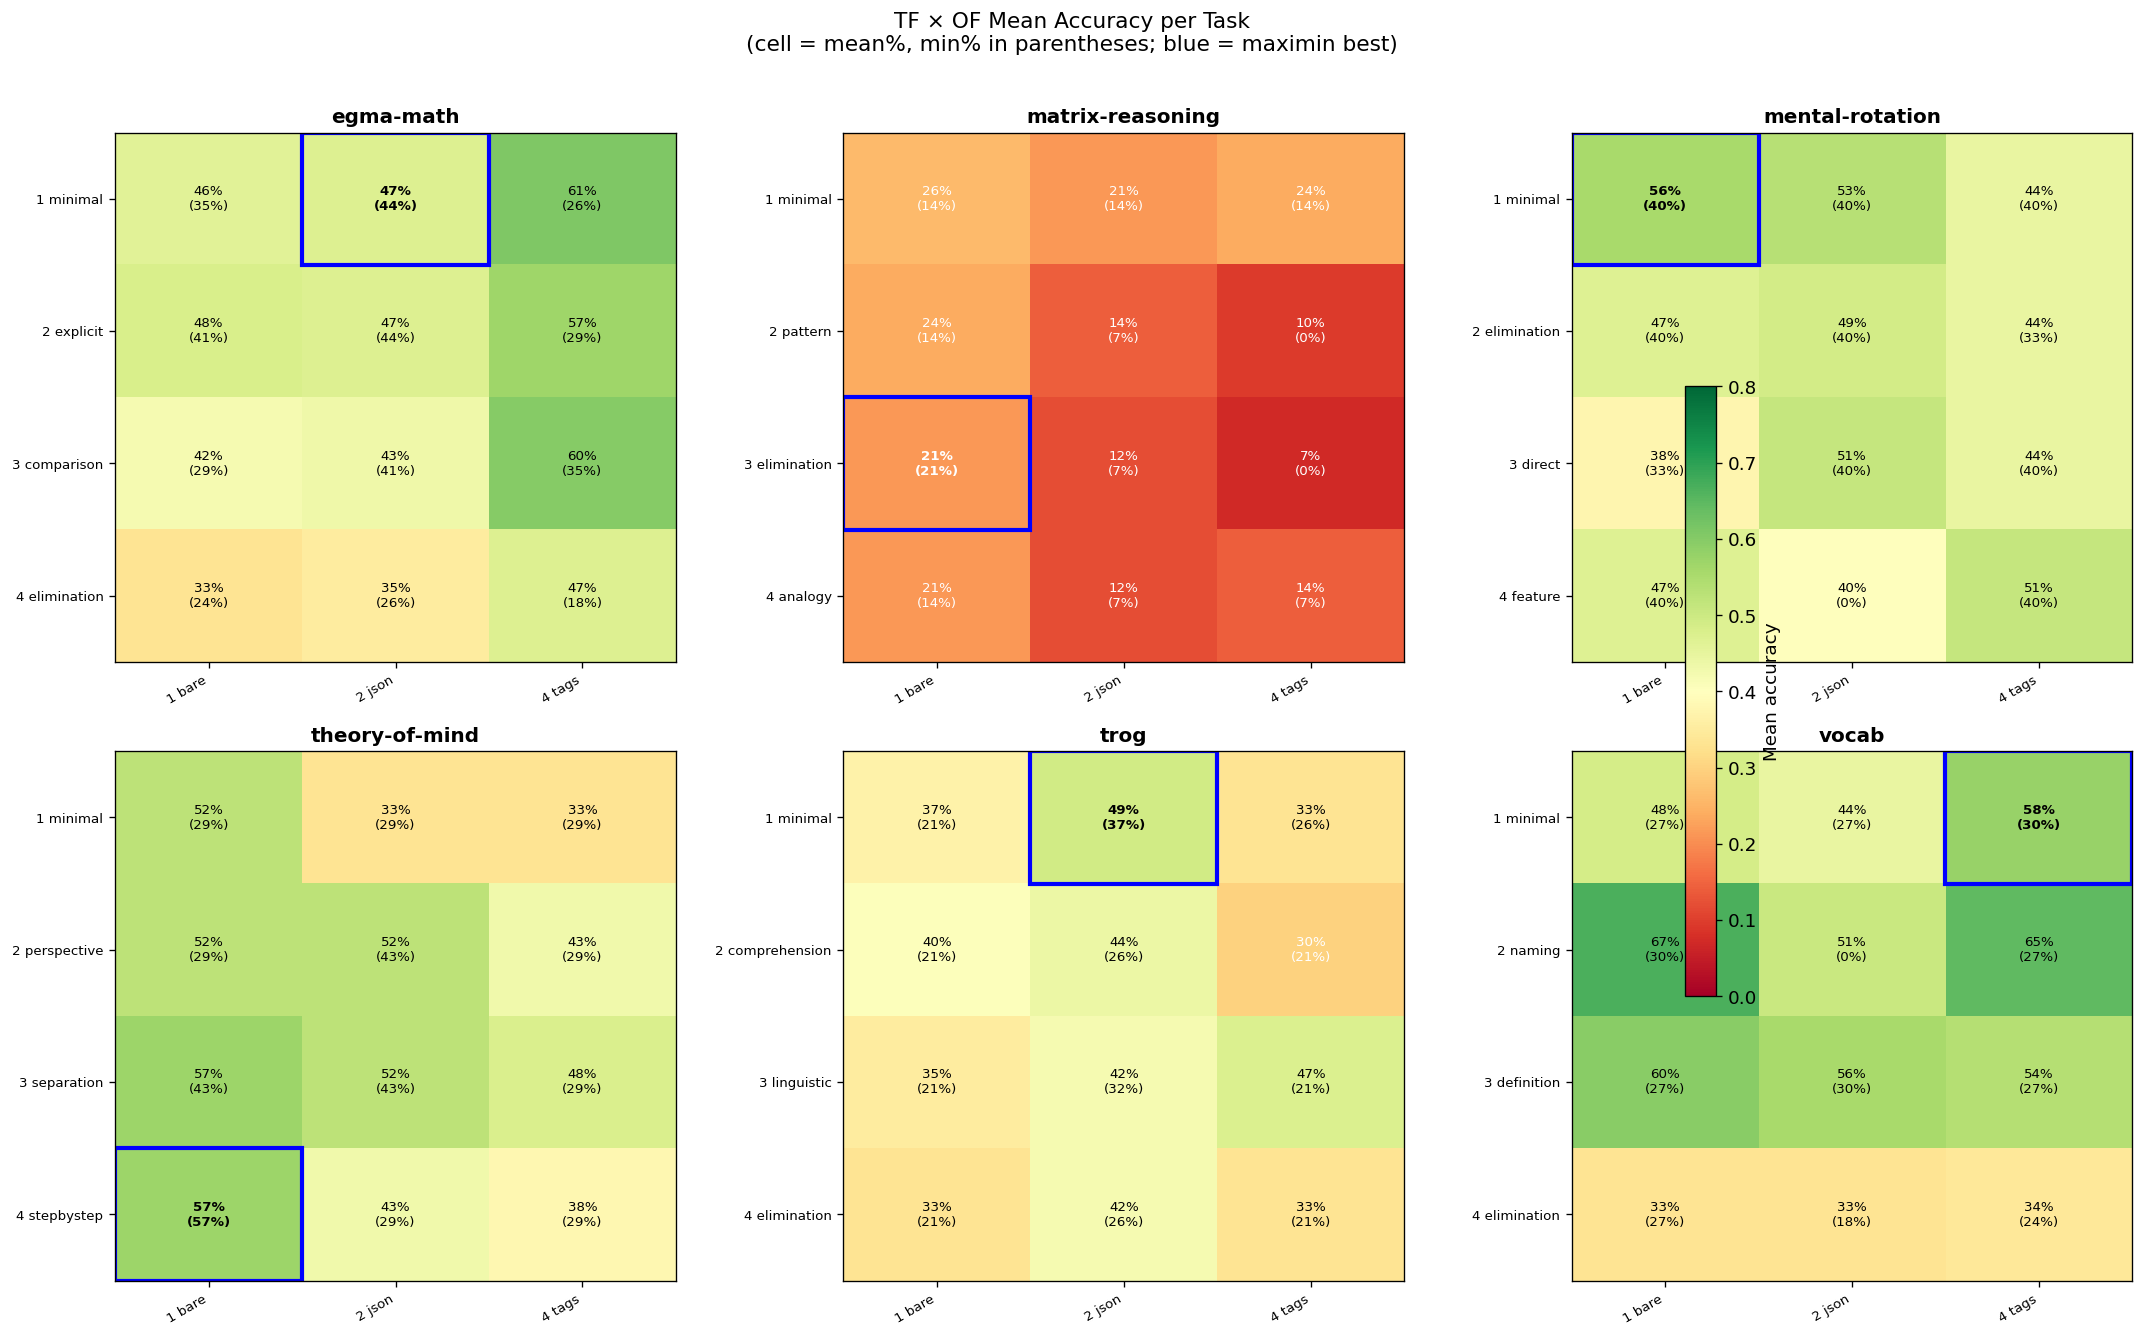

In [3]:
tasks = sorted(df["task"].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

best_per_task = {}

for idx, task in enumerate(tasks):
    ax = axes[idx]
    td = df[df["task"] == task]

    # Mean accuracy heatmap
    pivot_mean = td.pivot_table(
        index="task_framing", columns="output_format",
        values="accuracy", aggfunc="mean"
    )
    # Min accuracy (for maximin)
    pivot_min = td.pivot_table(
        index="task_framing", columns="output_format",
        values="accuracy", aggfunc="min"
    )

    # Find maximin cell
    best_idx = pivot_min.stack().idxmax()
    best_per_task[task] = {
        "tf": best_idx[0], "of": best_idx[1],
        "min_acc": pivot_min.loc[best_idx[0], best_idx[1]],
        "mean_acc": pivot_mean.loc[best_idx[0], best_idx[1]],
    }

    im = ax.imshow(pivot_mean.values, cmap="RdYlGn", vmin=0, vmax=0.8, aspect="auto")

    # Annotate cells
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            mean_val = pivot_mean.values[i, j]
            min_val = pivot_min.values[i, j]
            tf_name = pivot_mean.index[i]
            of_name = pivot_mean.columns[j]
            is_best = (tf_name == best_idx[0]) and (of_name == best_idx[1])
            weight = "bold" if is_best else "normal"
            color = "black" if mean_val > 0.3 else "white"
            ax.text(j, i, f"{mean_val:.0%}\n({min_val:.0%})",
                    ha="center", va="center", fontsize=8,
                    fontweight=weight, color=color)
            if is_best:
                rect = plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                     linewidth=2.5, edgecolor="blue", facecolor="none")
                ax.add_patch(rect)

    ax.set_xticks(range(len(pivot_mean.columns)))
    ax.set_xticklabels([c.replace("OF", "").replace("_", " ") for c in pivot_mean.columns],
                       rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot_mean.index)))
    ax.set_yticklabels([r.replace("TF", "").replace("_", " ") for r in pivot_mean.index],
                       fontsize=8)
    ax.set_title(task, fontsize=12, fontweight="bold")

fig.suptitle("TF × OF Mean Accuracy per Task\n(cell = mean%, min% in parentheses; blue = maximin best)",
             fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, shrink=0.6, label="Mean accuracy")
plt.tight_layout()
plt.savefig("../../results/prompt_robustness/heatmaps_tf_of.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Output Format Comparison (Marginalized over TF)

Which output format is most robust across all tasks and models?

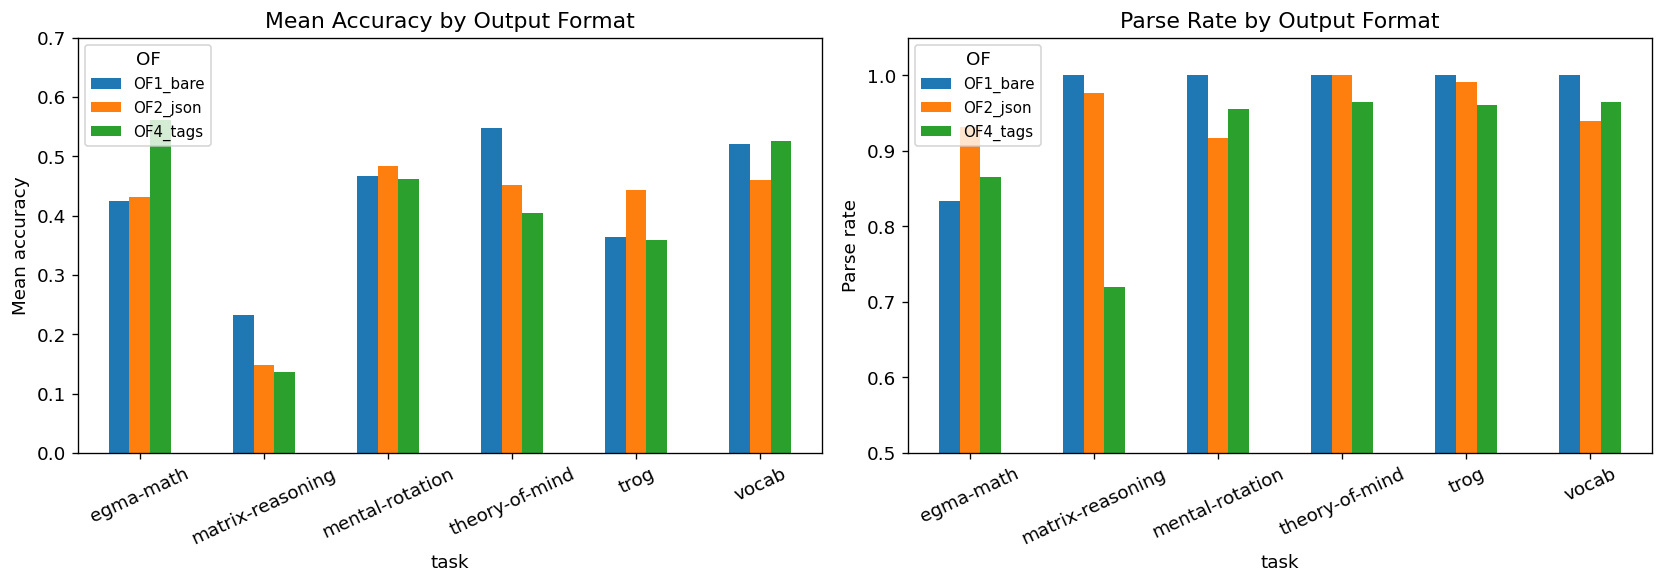


Global OF summary (across all tasks × models):
               mean_acc  min_acc  std_acc  mean_parse
output_format                                        
OF1_bare          0.426    0.143    0.188       0.972
OF2_json          0.403    0.000    0.186       0.959
OF4_tags          0.408    0.000    0.217       0.905


In [4]:
of_by_task = df.groupby(["task", "output_format"]).agg(
    mean_acc=("accuracy", "mean"),
    min_acc=("accuracy", "min"),
    std_acc=("accuracy", "std"),
    mean_parse=("parse_rate", "mean"),
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Mean accuracy by OF per task
pivot_of = df.pivot_table(index="task", columns="output_format", values="accuracy", aggfunc="mean")
pivot_of.plot(kind="bar", ax=axes[0], rot=25)
axes[0].set_ylabel("Mean accuracy")
axes[0].set_title("Mean Accuracy by Output Format")
axes[0].legend(title="OF", fontsize=9)
axes[0].set_ylim(0, 0.7)

# Panel B: Parse rate by OF per task
pivot_parse = df.pivot_table(index="task", columns="output_format", values="parse_rate", aggfunc="mean")
pivot_parse.plot(kind="bar", ax=axes[1], rot=25)
axes[1].set_ylabel("Parse rate")
axes[1].set_title("Parse Rate by Output Format")
axes[1].legend(title="OF", fontsize=9)
axes[1].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig("../../results/prompt_robustness/of_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGlobal OF summary (across all tasks × models):")
of_global = df.groupby("output_format").agg(
    mean_acc=("accuracy", "mean"),
    min_acc=("accuracy", "min"),
    std_acc=("accuracy", "std"),
    mean_parse=("parse_rate", "mean"),
).round(3)
print(of_global)

## 4. Task Framing Effect (Marginalized over OF)

Since each task has different TF names, we compare the rank of framings within each task.

In [5]:
print("Best task framing per task (maximin across models):")
print("=" * 70)
for task in tasks:
    td = df[df["task"] == task]
    tf_stats = td.groupby("task_framing").agg(
        mean_acc=("accuracy", "mean"),
        min_acc=("accuracy", "min"),
        mean_parse=("parse_rate", "mean"),
    ).sort_values("min_acc", ascending=False)
    best_tf = tf_stats.index[0]
    print(f"\n{task}:")
    print(tf_stats.round(3).to_string())

Best task framing per task (maximin across models):

egma-math:
                 mean_acc  min_acc  mean_parse
task_framing                                  
TF2_explicit        0.507    0.294       0.899
TF3_comparison      0.484    0.294       0.899
TF1_minimal         0.513    0.265       0.915
TF4_elimination     0.386    0.176       0.794

matrix-reasoning:
                 mean_acc  min_acc  mean_parse
task_framing                                  
TF1_minimal         0.238    0.143       0.984
TF4_analogy         0.159    0.071       0.873
TF2_pattern         0.159    0.000       0.913
TF3_elimination     0.135    0.000       0.825

mental-rotation:
                 mean_acc  min_acc  mean_parse
task_framing                                  
TF1_minimal         0.511    0.400       0.978
TF2_elimination     0.467    0.333       1.000
TF3_direct          0.444    0.333       0.985
TF4_feature         0.459    0.000       0.867

theory-of-mind:
                 mean_acc  min_acc  

## 5. Model Family Interaction

Do different model families prefer different prompts? If the rankings differ substantially, a single "best prompt" may not exist.

<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/lh/s2wfdq9s0kdffmcbt5q8txg00000gn/T/ipykernel_13321/2390695704.py:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  td["cell"] = td["task_framing"].str.replace("TF\d+_", "", regex=True) + "×" + td["output_format"].str.replace("OF\d+_", "", regex=True)
/var/folders/lh/s2wfd

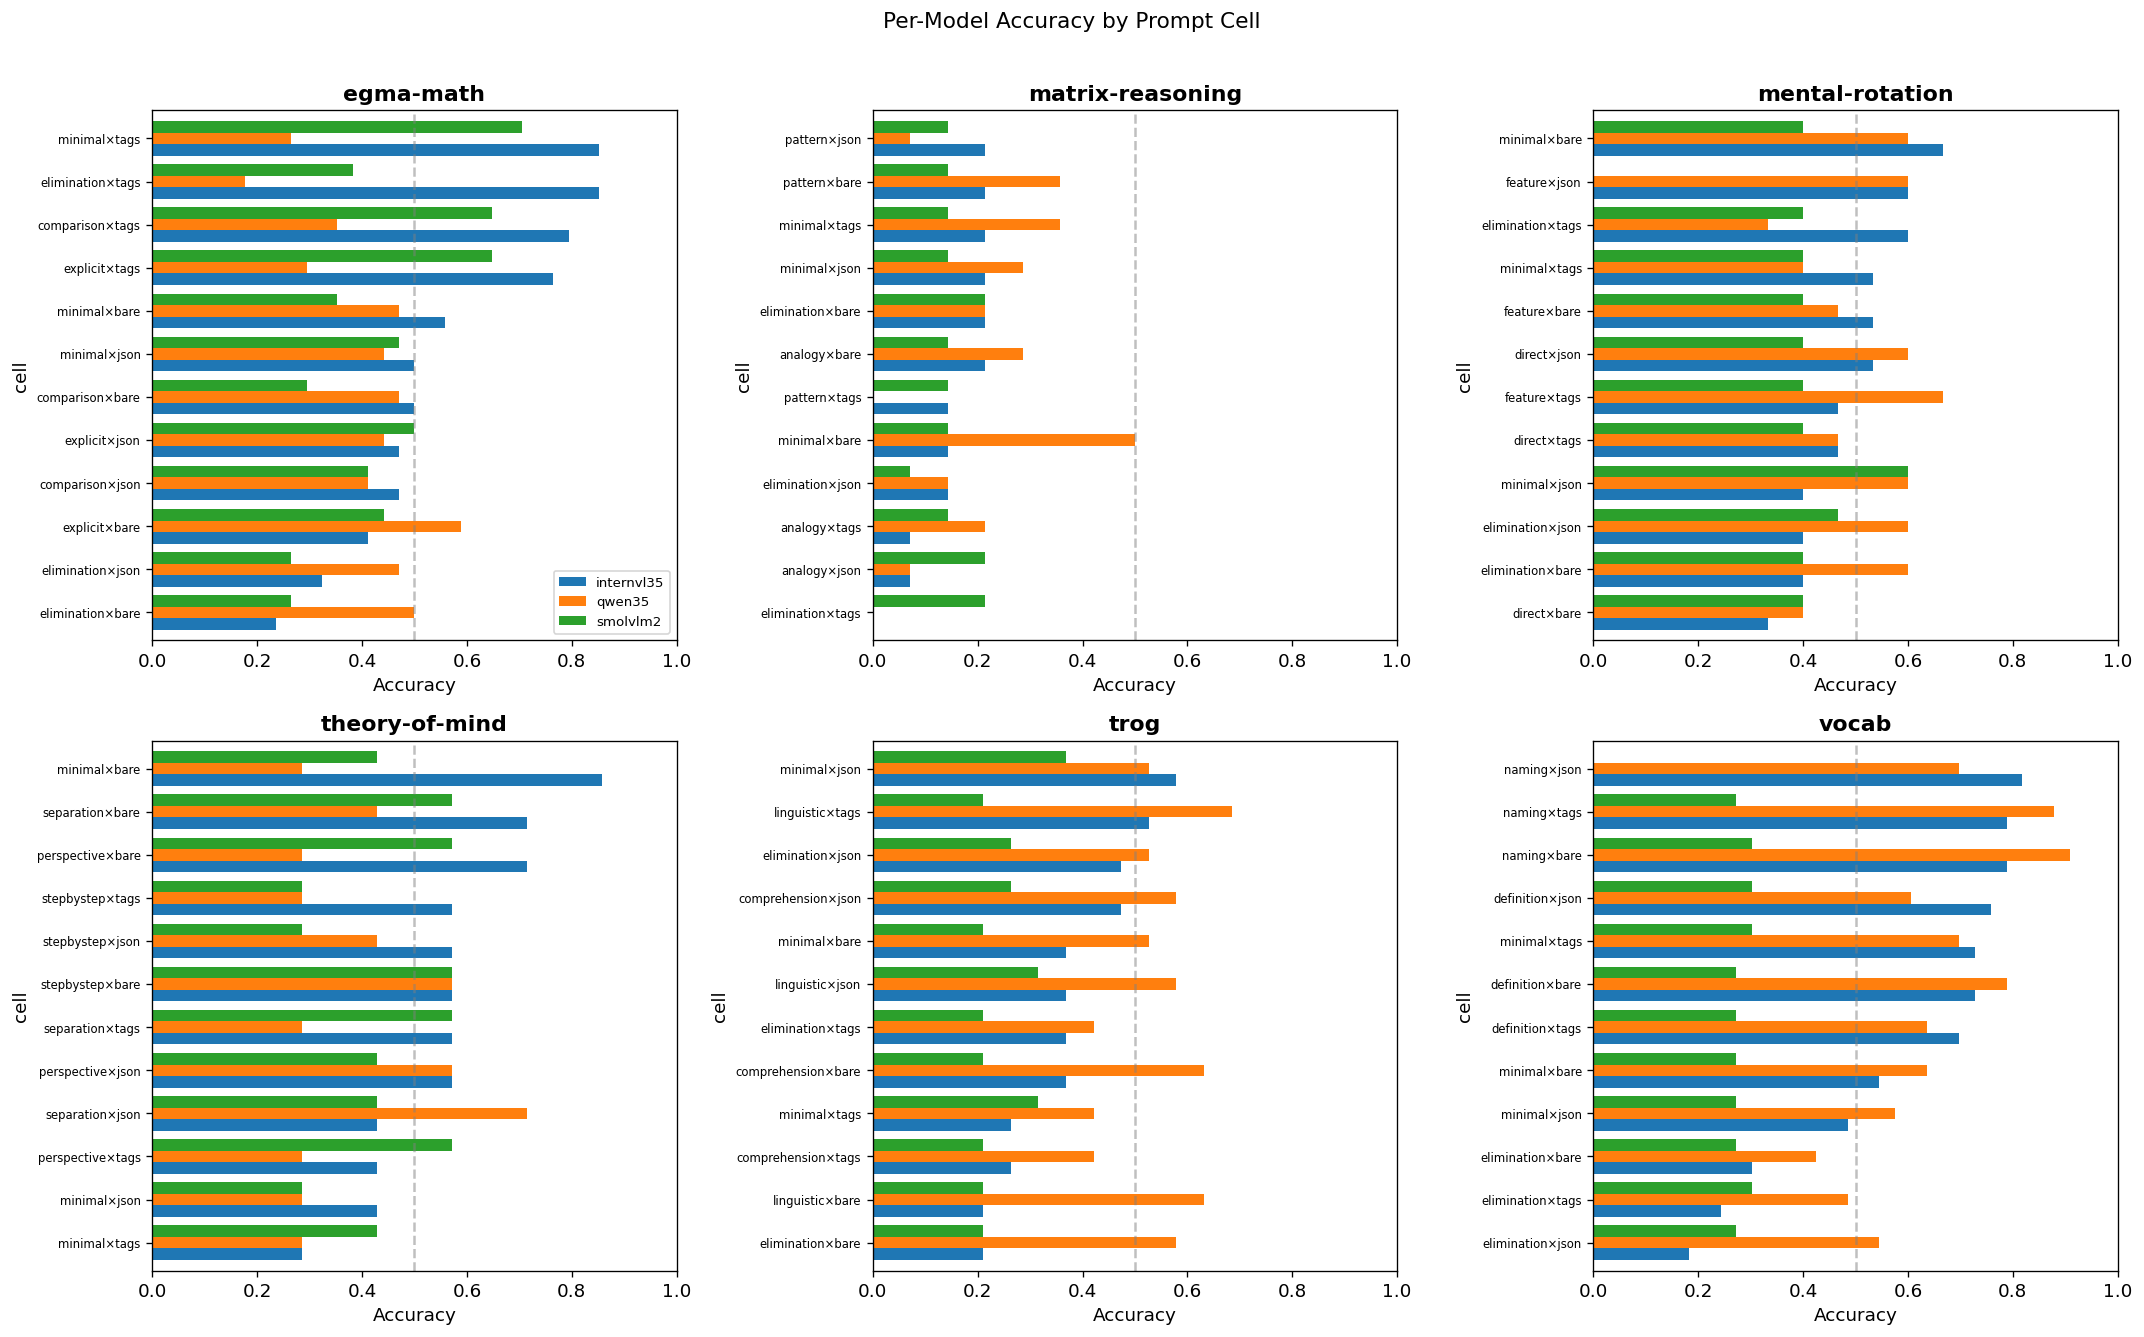

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
models = sorted(df["model"].unique())

for idx, task in enumerate(tasks):
    ax = axes[idx]
    td = df[df["task"] == task]
    td = td.copy()
    td["cell"] = td["task_framing"].str.replace("TF\d+_", "", regex=True) + "×" + td["output_format"].str.replace("OF\d+_", "", regex=True)

    pivot = td.pivot_table(index="cell", columns="model", values="accuracy")
    pivot = pivot.sort_values(by=models[0], ascending=True)

    pivot.plot(kind="barh", ax=ax, width=0.8)
    ax.set_title(task, fontweight="bold")
    ax.set_xlabel("Accuracy")
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)
    if idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(fontsize=8, loc="lower right")
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Per-Model Accuracy by Prompt Cell", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../../results/prompt_robustness/model_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Bias Analysis

Does the prompt configuration affect response bias? Values near 0.5 indicate balanced predictions; values near 1.0 indicate extreme bias toward one label.

/var/folders/lh/s2wfdq9s0kdffmcbt5q8txg00000gn/T/ipykernel_13321/3215804698.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


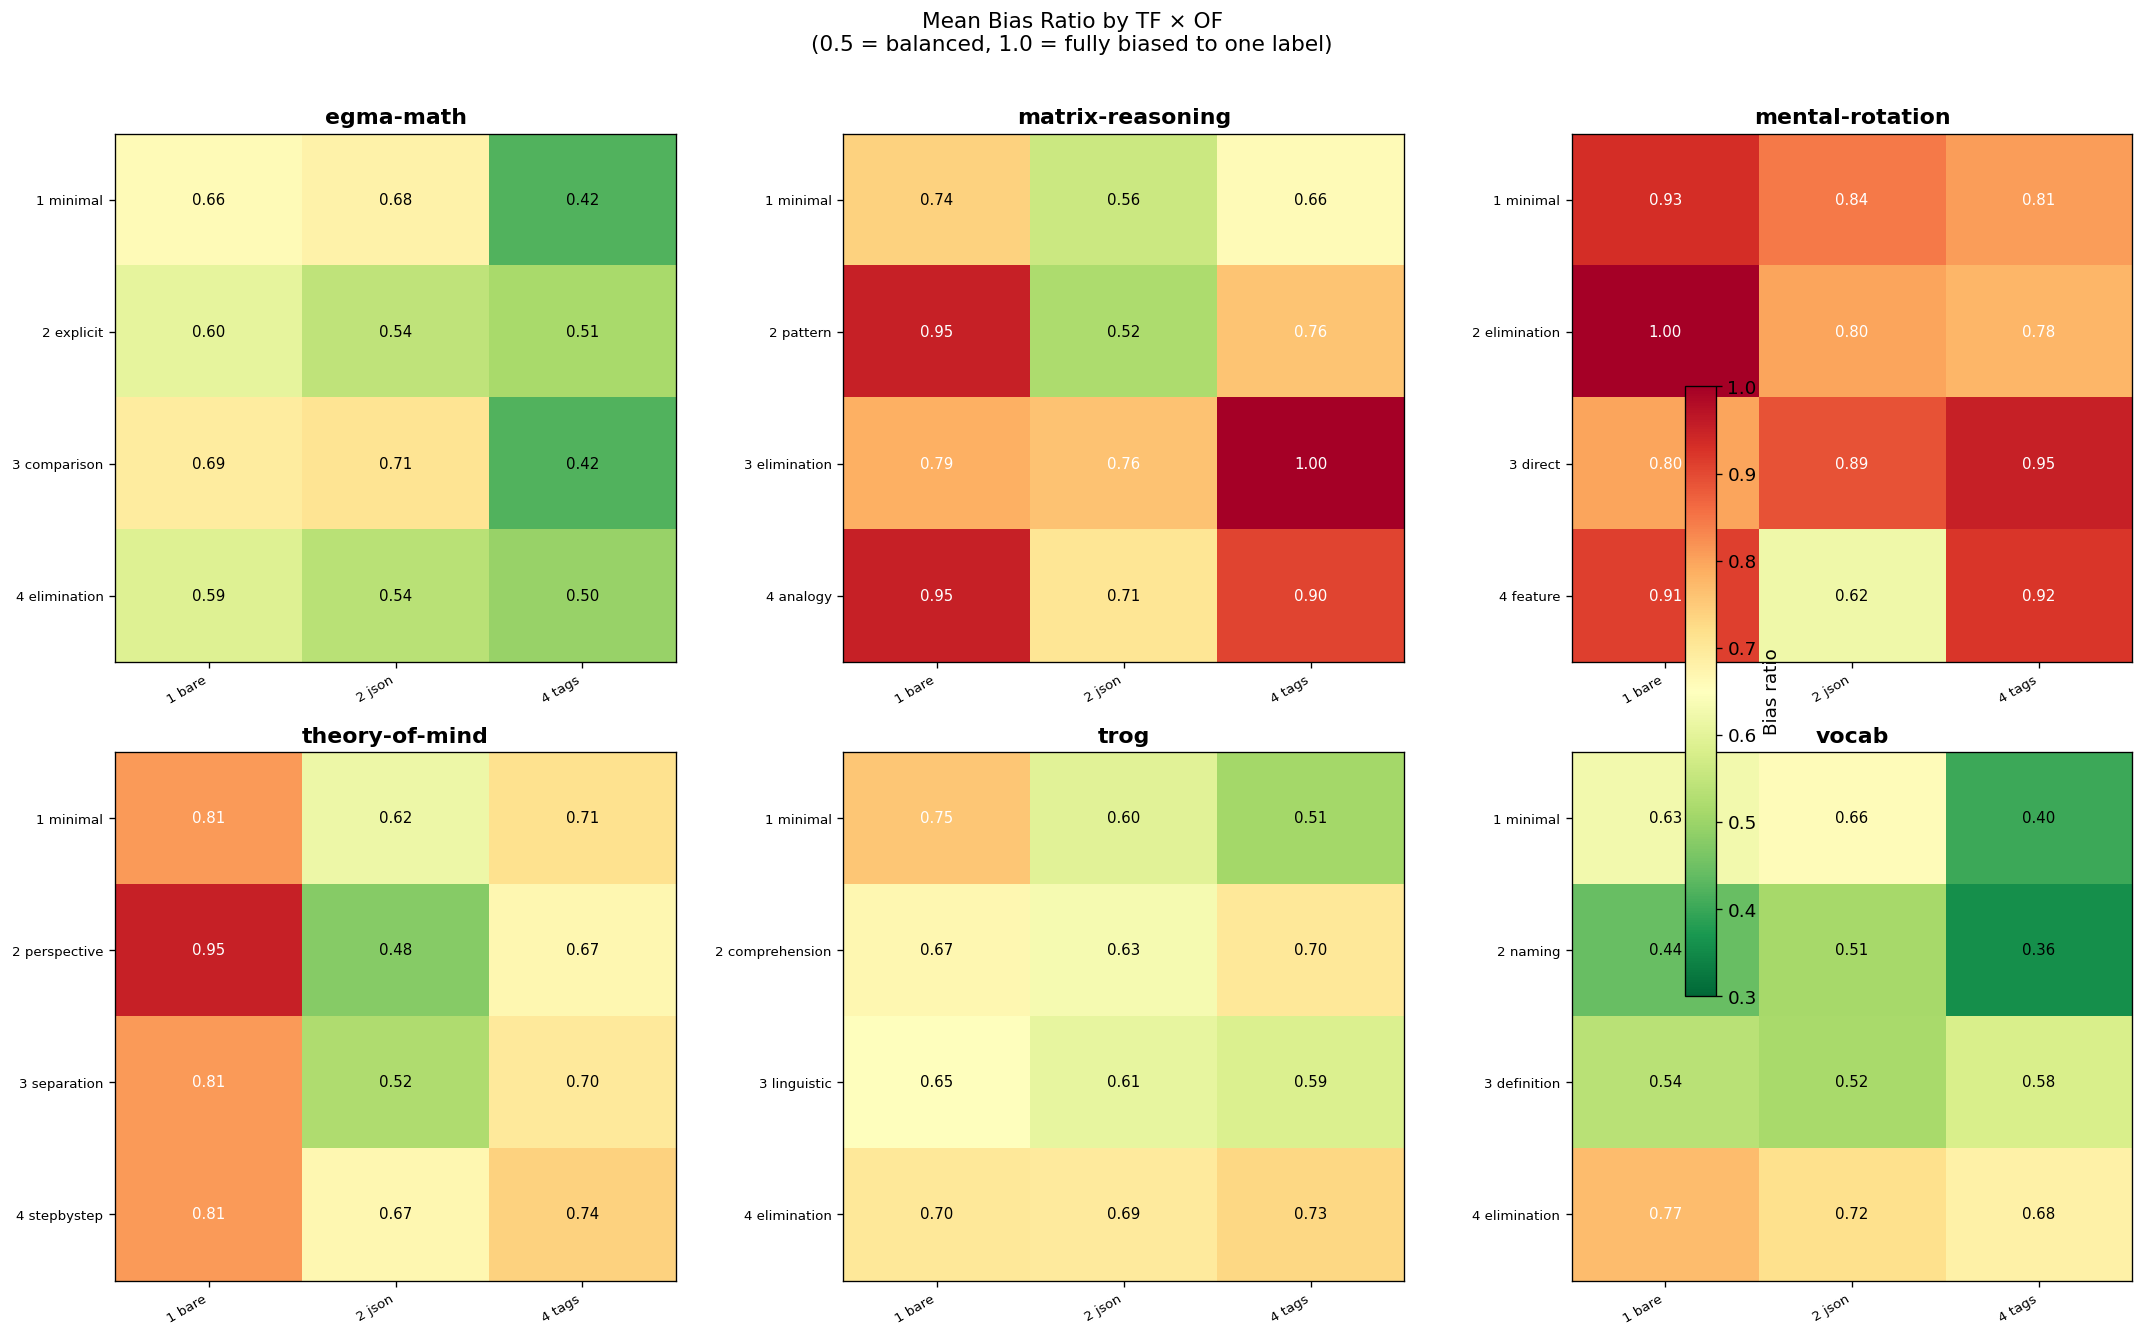

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, task in enumerate(tasks):
    ax = axes[idx]
    td = df[df["task"] == task]
    pivot_bias = td.pivot_table(
        index="task_framing", columns="output_format",
        values="bias_ratio", aggfunc="mean"
    )
    im = ax.imshow(pivot_bias.values, cmap="RdYlGn_r", vmin=0.3, vmax=1.0, aspect="auto")
    for i in range(pivot_bias.shape[0]):
        for j in range(pivot_bias.shape[1]):
            val = pivot_bias.values[i, j]
            color = "white" if val > 0.75 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)
    ax.set_xticks(range(len(pivot_bias.columns)))
    ax.set_xticklabels([c.replace("OF", "").replace("_", " ") for c in pivot_bias.columns],
                       rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot_bias.index)))
    ax.set_yticklabels([r.replace("TF", "").replace("_", " ") for r in pivot_bias.index], fontsize=8)
    ax.set_title(task, fontweight="bold")

fig.suptitle("Mean Bias Ratio by TF × OF\n(0.5 = balanced, 1.0 = fully biased to one label)",
             fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, shrink=0.6, label="Bias ratio")
plt.tight_layout()
plt.savefig("../../results/prompt_robustness/bias_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Maximin Recommendations

The **maximin criterion** selects the TF × OF combination that maximizes the *worst-case* accuracy across all models. This is the most conservative and robust choice for a benchmark that will be used with unknown future models.

In [8]:
recs = pd.read_csv("../../results/prompt_robustness/analysis/recommendations.csv")
recs.columns = ["Task", "Best TF", "Best OF", "Min Acc (worst model)", "Mean Acc"]
recs["Min Acc (worst model)"] = recs["Min Acc (worst model)"].map("{:.1%}".format)
recs["Mean Acc"] = recs["Mean Acc"].map("{:.1%}".format)
print("Recommended prompt per task (maximin criterion):")
print("=" * 70)
print(recs.to_string(index=False))

Recommended prompt per task (maximin criterion):
            Task         Best TF  Best OF Min Acc (worst model) Mean Acc
       egma-math     TF1_minimal OF2_json                 44.1%    47.1%
matrix-reasoning TF3_elimination OF1_bare                 21.4%    21.4%
 mental-rotation     TF1_minimal OF1_bare                 40.0%    55.6%
  theory-of-mind  TF4_stepbystep OF1_bare                 57.1%    57.1%
            trog     TF1_minimal OF2_json                 36.8%    49.1%
           vocab     TF1_minimal OF4_tags                 30.3%    57.6%


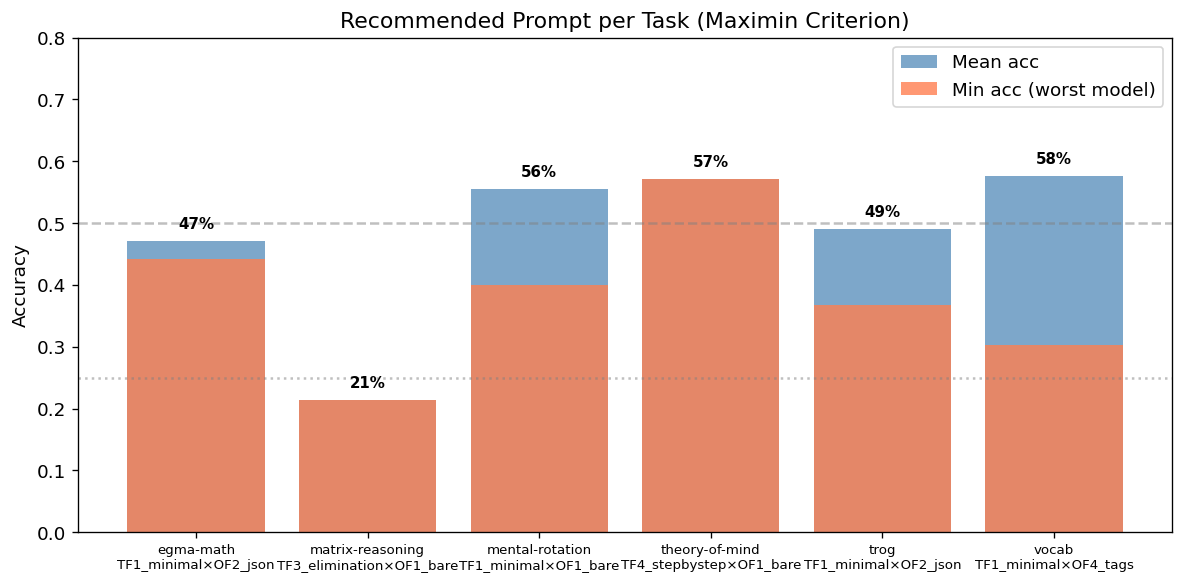

In [9]:
# Summary bar chart
recs_raw = pd.read_csv("../../results/prompt_robustness/analysis/recommendations.csv")

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(recs_raw))
bars_mean = ax.bar(x, recs_raw["best_mean_acc"], color="steelblue", alpha=0.7, label="Mean acc")
bars_min = ax.bar(x, recs_raw["best_min_acc"], color="coral", alpha=0.8, label="Min acc (worst model)")

ax.set_xticks(x)
labels = [f"{row['task']}\n{row['best_tf']}×{row['best_of']}" for _, row in recs_raw.iterrows()]
ax.set_xticklabels(labels, fontsize=8, ha="center")
ax.set_ylabel("Accuracy")
ax.set_title("Recommended Prompt per Task (Maximin Criterion)")
ax.legend()
ax.set_ylim(0, 0.8)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="chance (2-opt)")
ax.axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="chance (4-opt)")

for i, row in recs_raw.iterrows():
    ax.text(i, row["best_mean_acc"] + 0.02, f"{row['best_mean_acc']:.0%}",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../../results/prompt_robustness/recommendations_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusions

### Output Format

- **OF1_bare** (just output the letter) is the most robust output format globally: highest maximin accuracy and highest parse rate (100% on most tasks).
- **OF2_json** is a close second with slightly better structured parsing but marginally lower accuracy.
- **OF4_tags** (`<answer>` tags) shows high variance: excellent on some model-task combos but catastrophic (0%) on others. Not recommended as a default.
- **OF3_cot** (chain-of-thought) was excluded because it is 3-4× slower and yields low parse rates (14-57%).

### Task Framing

- **TF1_minimal** wins on 4/6 tasks under the maximin criterion — simple, direct prompts generalize best across models.
- More elaborate framings (elimination, feature-grounded) sometimes help specific models but hurt others, reducing worst-case performance.
- The optimal TF is task-dependent: theory-of-mind benefits from step-by-step framing, while most other tasks prefer minimal.

### Model Family Interaction

- TF rankings vary across model families (e.g., InternVL prefers minimal framing while Qwen prefers explicit framing on several tasks).
- OF rankings are more stable across families — the format dimension is less model-dependent than the framing dimension.
- This supports using a **shared OF** (bare or JSON) with **task-specific TF** as the recommended configuration.

### Bias

- Prompt configuration significantly affects response bias. Tags format tends to produce less biased responses but at the cost of parse reliability.
- Elimination framing amplifies bias on several tasks, particularly for smaller models.

### Recommended Default Configuration

| Task | Task Framing | Output Format | Min Acc | Mean Acc |
|------|-------------|---------------|---------|----------|
| egma-math | TF1_minimal | OF2_json | 44.1% | 47.1% |
| matrix-reasoning | TF3_elimination | OF1_bare | 21.4% | 21.4% |
| mental-rotation | TF1_minimal | OF1_bare | 40.0% | 55.6% |
| theory-of-mind | TF4_stepbystep | OF1_bare | 57.1% | 57.1% |
| trog | TF1_minimal | OF2_json | 36.8% | 49.1% |
| vocab | TF1_minimal | OF4_tags | 30.3% | 57.6% |

### Limitations

- Evaluated on 20% stratified subset — accuracy estimates have wider confidence intervals for small tasks (e.g., theory-of-mind with 7 trials).
- Only 3 small models tested. Results should be validated on larger models (4B+) and API models (GPT, Gemini).
- CoT was excluded; a separate evaluation with higher token budgets may reveal different patterns for reasoning-heavy tasks.